# 04. Quench dynamics 

01r Rydberg quench / 制备 across backends。四个 Part 各自自包含(各自有 imports 和 segment-shim)。
**4×4 quench benchmark**:Δ-sweep quench,exact / MPS / PEPS 对照 + 独立 10×10 PEPS。

合并自 `run_quench_benchmark` + `01r_plus_quench_benchmark` + `plus_state_preparation`。

## Part A — 4×4 Rydberg quench benchmark(exact / MPS / PEPS + 10×10)

同一套 4×4 `1r` 方格 + 同一条失谐扫描 protocol。`1r` 每格两能级 `|1>`(基态)/ `|r>`(Rydberg),最近邻 VdW:

$$
H(t) = \sum_{i=0}^{15}\left[\frac{\Omega(t)}{2}\,\sigma^x_i - \Delta_i(t)\,n^r_i\right] + \sum_{\langle i,j\rangle} V_{ij}\,n^r_i n^r_j
$$

其中 $\sigma^x_i=|r\rangle\langle 1|_i+|1\rangle\langle r|_i$,$n^r_i=|r\rangle\langle r|_i$,$\Delta_i(t)=\Delta(t)+\Delta_{\mathrm{addr},i}(t)$,$V_{ij}=C_6/r_{ij}^6$(`mode="nn"` 只取最近邻)。$C_6=2\pi\times874\ \mathrm{GHz\cdot\mu m^6}$,故 $r=6\,\mu m$ 时 $V\approx2\pi\times18\ \mathrm{MHz}$,$r=10\,\mu m$ 时 $V\approx2\pi\times0.874\ \mathrm{MHz}$。角频率均为 rad/s。

后端:`exact` 基准,`mps`(TeNPy CPU)、`peps`(YASTN finite,二维主路径)。

In [1]:
# Pin BLAS/OpenMP to 1 thread BEFORE importing numpy/scipy/tenpy.
# Small TN tensors (DMRG/TDVP/PEPS) => multi-threaded BLAS oversubscribes
# cores and runs 10-40x SLOWER on a loaded box. This cell must stay first
# and run before any import: the libraries read these variables only once,
# at import time.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

BLAS/OpenMP threads pinned to 1


In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt
import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register

两条平滑波形,先升 Rabi/detuning 再降。

**Sweep 时间上界(decay)**:300 K 下 70S Rydberg decay $\Gamma=1/151.55\ \mu s^{-1}$。要单原子存活率 $>0.99$(loss $<1\%$),需 $e^{-\Gamma t}>0.99 \Rightarrow t\lesssim -\ln(0.99)\times151.55\ \mu s\approx 1.52\ \mu s$,故 sweep 不能太久(本 notebook 取 1.5 μs)。

- **Rabi** smooth flat-top:smootherstep $h(u)=10u^3-15u^4+6u^5$ 平滑开、保持平台、再平滑关;平台边缘宽 $\tau_r=0.09T$。两次共振穿越附近 $\Omega/2$ 已在平台上,avoided-crossing gap 足够大,扫回时更易把多体态带回基态。
- **Detuning** 余弦往返:$\Delta(t)=\Delta_{\rm mid}-\Delta_{\rm amp}\cos(2\pi t/T)$,$\Delta_{\rm mid}=(\Delta_{\rm start}+\Delta_{\rm end})/2$、$\Delta_{\rm amp}=(\Delta_{\rm end}-\Delta_{\rm start})/2$,取值 $-10\to+10\to-10$ MHz、端点斜率为零。

实现提示:detuning 由 chirp AOM RF / EOM-PLL / 直接调激光频率给出,AWG 输出连续相位 $\phi(t)=2\pi\int f_{\rm RF}(t)\,dt$。AOM 调 Rabi 光强时链路 $V_{\rm AWG}\to P_{\rm RF}\to P_{\rm opt}\to\Omega$,欲 $\Omega\propto b(t)$ 通常需 $P_{\rm opt}\propto b(t)^2$;故 `omega_half_t` 是目标 Rabi envelope,实际 AWG 电压按测得的 AOM transfer function 反推。

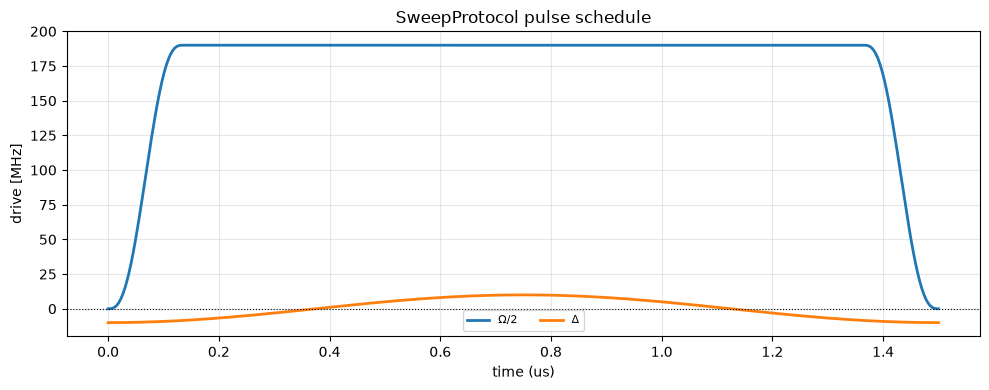

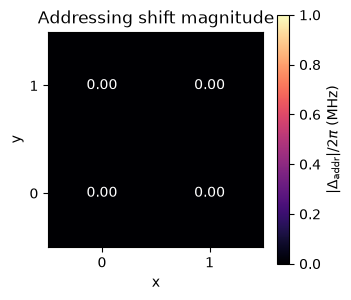

In [5]:
# No local-addressing detuning shift for this run.
Lx = 2
Ly = 2
N_sites = Lx * Ly

# Experimental-style parameters
a_um = 5                         # lattice spacing, um
C6_70s = 2 * np.pi * 874e9         # rad/s * um^6, Rb 70S typical

local_detuning_offsets = np.zeros(N_sites)
# 1. 几何 + 能级结构：4x4 方格，每个格点是 |1>(基态) / |r>(Rydberg) 两能级
geom = Register.rectangle(Lx, Ly, spacing_um=a_um)


Omega = 2 * np.pi * 380e6          # rad/s
delta_start = -2 * np.pi * 10.0e6   # rad/s
delta_end = 2 * np.pi * 10.0e6      # rad/s
t_sweep = 1.5e-6                   # s
omega_ramp_frac = 0.1

# Effectively global Rabi
def omega_half_t(t):
    ramp_frac = 0.09
    s = np.clip(t / max(t_sweep, np.finfo(float).eps), 0.0, 1.0)

    def smoothstep5(u):
        u = np.clip(u, 0.0, 1.0)
        return 10.0 * u**3 - 15.0 * u**4 + 6.0 * u**5

    if s < ramp_frac:
        env = smoothstep5(s / ramp_frac)
    elif s > 1.0 - ramp_frac:
        env = smoothstep5((1.0 - s) / ramp_frac)
    else:
        env = 1.0

    return 0.5 * Omega * env

# 全局 Rydberg 失谐：平滑往返扫频 -10 MHz -> +10 MHz -> -10 MHz
def delta_t(t):
    s = np.clip(t / max(t_sweep, np.finfo(float).eps), 0.0, 1.0)
    delta_mid = 0.5 * (delta_start + delta_end)
    delta_amp = 0.5 * (delta_end - delta_start)
    return delta_mid - delta_amp * np.cos(2.0 * np.pi * s)

# 局部 addressing shift；这里全部为 0
def delta_local(t, ind):
    return local_detuning_offsets[ind]

# 2. 自定义 sweep：global Delta(t) 和 local address shift 分开输入
protocol = rg.SweepProtocol(
    t_gate=t_sweep,
    omega_half_fn=omega_half_t,
    delta_fn=delta_t,
    address_fn=delta_local,
    n_steps=120,
)
system = rg.RydbergSystem.from_lattice(
    geom, "1r",
    interaction=InteractionSpec(C6=C6_70s, mode="nn"),       # 近邻 VdW；TN 勿用默认 all
    protocol=protocol,
)
t_eval = np.linspace(0.0, t_sweep, 7)

protocol.plot(
    system=system,
    unit_scale=1.0 / (2 * np.pi * 1e6), unit_label="MHz",
    time_scale=1e6, time_label="time (us)",
)
protocol.plot_address_map(system=system)

# 设置 TN 时间步长
dt_tn = 0.2 / Omega  # seconds; 0.2 * Omega^{-1}, same time unit as t_sweep/t_eval


## 3. Exact state-vector baseline

`backend="exact_dense"`：演化至 sweep 终点 $T$，每段对完整 $H$ 做精确矩阵指数（无 Trotter 误差，仅段内 $H$ 常数化的离散误差）。与初态 $|1\rangle^{\otimes N}$ 的重叠给出返回概率和累积动力学相位 $\phi=\mathrm{arg}\langle\psi_0|\psi(T)\rangle$——所有近似后端的相位基准。

In [9]:
# 3a. 精确后端：演化至终点，读相对初态的返回概率与动力学相位。
method = "exact_dense"
_t0 = time.perf_counter()
res = rg.simulate(system, [], "all_ground", backend="exact_dense")
exact_elapsed = time.perf_counter() - _t0

psi0 = system.ground_state()
overlap = np.vdot(psi0, res.psi_final)
exact_return = float(abs(overlap) ** 2)
exact_phase = float(np.angle(overlap))

print(f"Exact elapsed: {exact_elapsed:.3f} s")
print(f"T = {system.protocol.t_gate * 1e6:.3f} us")
print(f"return prob  = {exact_return:.6f}")
print(f"phase (rad)  = {exact_phase:+.6f}")
print(f"phase/pi     = {exact_phase / np.pi:+.6f}")


Exact elapsed: 0.168 s
T = 1.500 us
return prob  = 0.063758
phase (rad)  = +2.335116
phase/pi     = +0.743290


In [7]:
# 3a. 精确后端：states 是态矢量，用 system.expectation 读 Rydberg 均值和逐格点 occupation。
method = "exact"
_t0 = time.perf_counter()
res = rg.simulate(system, [], "all_ground", backend="exact_dense", t_eval=t_eval)
exact_elapsed = time.perf_counter() - _t0

exact_n_mean = np.asarray([
    system.expectation("sum_nr", psi) / system.N
    for psi in res.states
])
exact_n_i = np.asarray([
    [system.expectation(f"n_r_{i}", psi) for i in range(system.N)]
    for psi in res.states
])

print(f"Exact elapsed: {exact_elapsed:.3f} s")
print("time(us)  exact <n_r>")
for t, exact_val in zip(res.times * 1e6, exact_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}")


Exact elapsed: 0.161 s
time(us)  exact <n_r>
  0.000       0.0000
  0.250       0.5136
  0.500       0.5264
  0.750       0.3912
  1.000       0.4243
  1.250       0.5724
  1.500       0.4636


### 逐格点 occupation color map

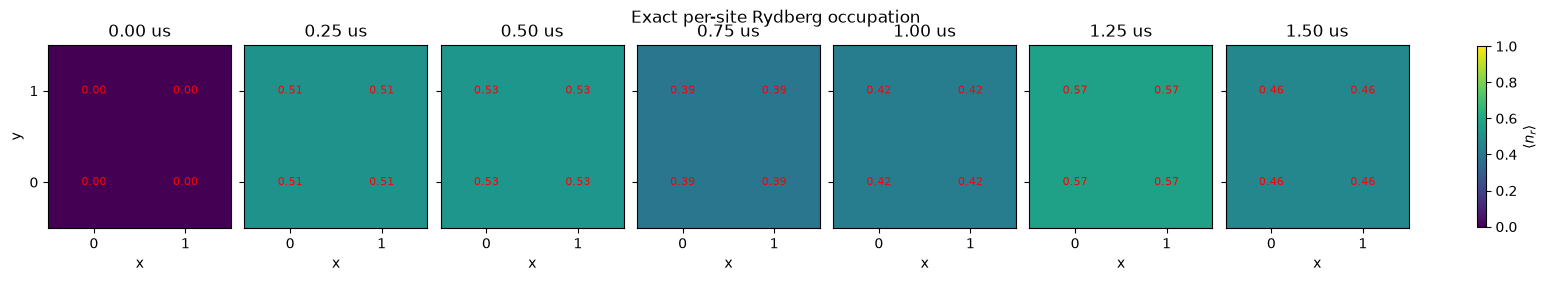

In [8]:
# 3b. 每个时刻的 4x4 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
if exact_n_i is None:
    print("exact has no successful data to plot.")
else:
    fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
    axes_h = np.atleast_1d(axes_h)

    for ax_h, t, occ in zip(axes_h, res.times, exact_n_i):
        grid = occ.reshape(Lx, Ly)
        im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax_h.set_title(f"{t * 1e6:.2f} us")
        ax_h.set_xticks(range(Lx))
        ax_h.set_yticks(range(Ly))
        ax_h.set_xlabel("x")
        if ax_h is axes_h[0]:
            ax_h.set_ylabel("y")
        else:
            ax_h.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                val = grid[ix, iy]
                txt_color = "red"
                ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

    fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
    fig_h.suptitle("Exact per-site Rydberg occupation", y=1.05)
    plt.show()


## 4. TeNPy CPU MPS-TDVP (`mps`)

把 4×4 按 snake ordering 拉成一维 MPS、用 TeNPy TDVP 演化。关键参数 `chi_max`、`dt`;interaction 沿用 `system` 的最近邻 pair list。

In [6]:
# 4a. TeNPy MPS-TDVP (`backend="mps"`)：TN 后端把 <n_r> 和每个格点 <n_i> 记录在 metadata["obs"] 里。
method = "mps"
# 开始计时
_t0 = time.perf_counter()
#开始模拟
res_tenpy = rg.simulate(
    system, [], "all_ground",
    backend="mps", t_eval=t_eval, observables=["n_mean", "n_i"],
    backend_options={"chi_max": 32, "dt": dt_tn, "svd_min": 1e-10},
)
# 计时结束
tenpy_elapsed = time.perf_counter() - _t0
# 读取结果
tenpy_n_mean = np.asarray(res_tenpy.metadata["obs"]["n_mean"])
tenpy_n_i = np.asarray(res_tenpy.metadata["obs"]["n_i"])
# 计算误差
tenpy_diff_mean = float(np.max(np.abs(tenpy_n_mean - exact_n_mean))) if "exact_n_mean" in globals() else np.nan
tenpy_diff_i = float(np.max(np.abs(tenpy_n_i - exact_n_i))) if "exact_n_i" in globals() else np.nan

print(f"TeNPy elapsed: {tenpy_elapsed:.3f} s")
print("time(us)  exact <n_r>  TeNPy <n_r>")
for t, exact_val, tn_val in zip(t_eval * 1e6, exact_n_mean, tenpy_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}  {tn_val:10.4f}")
print(f"max |delta <n_r>| = {tenpy_diff_mean:.3e}; max |delta <n_i>| = {tenpy_diff_i:.3e}")



/home/chance/Ryd-gate-modeling/.venv/lib/python3.10/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


TeNPy elapsed: 286.134 s
time(us)  exact <n_r>  TeNPy <n_r>
  0.000       0.0000      0.0000
  0.250       0.1081      0.1084
  0.500       0.8432      0.8429
  0.750       0.9609      0.9610
  1.000       0.8285      0.8287
  1.250       0.1152      0.1152
  1.500       0.0024      0.0024
max |delta <n_r>| = 2.416e-04; max |delta <n_i>| = 4.966e-04


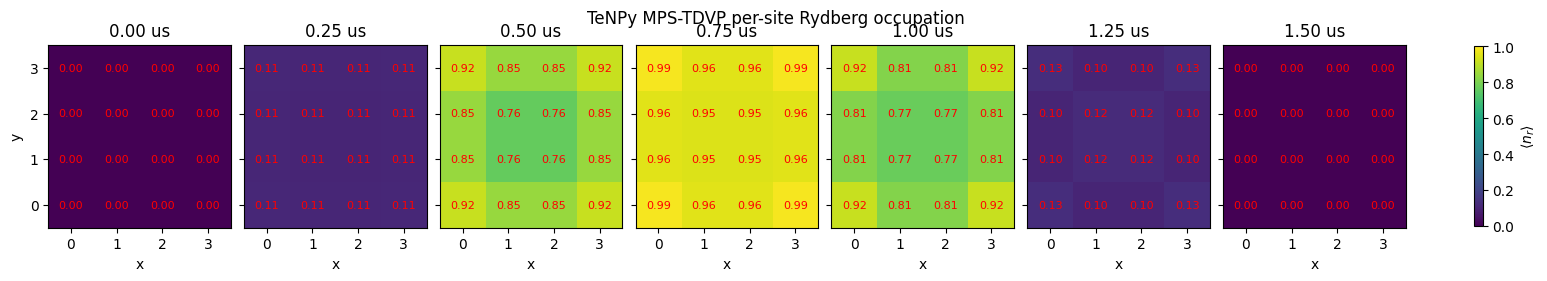

In [7]:
# 4b. 每个时刻的 4x4 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
if tenpy_n_i is None:
    print("mps has no successful data to plot.")
else:
    fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
    axes_h = np.atleast_1d(axes_h)

    for ax_h, t, occ in zip(axes_h, res_tenpy.times, tenpy_n_i):
        grid = occ.reshape(Lx, Ly)
        im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax_h.set_title(f"{t * 1e6:.2f} us")
        ax_h.set_xticks(range(Lx))
        ax_h.set_yticks(range(Ly))
        ax_h.set_xlabel("x")
        if ax_h is axes_h[0]:
            ax_h.set_ylabel("y")
        else:
            ax_h.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                val = grid[ix, iy]
                txt_color = "red"
                ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

    fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
    fig_h.suptitle("TeNPy MPS-TDVP per-site Rydberg occupation", y=1.05)
    plt.show()


## 6. finite-PEPS (`peps`)

finite-PEPS NTU 路径,保留二维方格几何;默认 NTU 更新 + BP measurement。设 `use_cuda=True, yastn_backend="torch", device="cuda"` 走 GPU。

In [ ]:
# 6a. YASTN finite-PEPS：二维 PEPS 主路径。
method = "peps"
# 开始计时
_t0 = time.perf_counter()

res_peps = rg.simulate(
    system, [], "all_ground",
    backend="peps", t_eval=t_eval, observables=["n_mean", "n_i"],
    backend_options={
        "chi_max": 10,
        "dt": dt_tn,
        "svd_min": 1e-8,
        "measurement_environment": "bp",
        "update_environment": "ntu",
        "max_iter": 10,
        # NTU 每条 bond 的迭代优化停在 tol_iter（相对截断误差不再下降即止），
        # 而非死磕到默认的 1e-12。chi=10 的截断地板 ~1.9e-2，把 tol 放宽到 1e-7
        # 只改变结果 ~7e-5（比地板低 ~250x），却把 evolution_step_ 提速 ~1.5x。
        # 想更激进可设 1e-5（~2x，误差仍 << 地板）；想要严格复现旧值设 1e-12。
        "tol_iter": 1e-7,
        "use_cuda": True,
        "yastn_backend": "torch",
        "device": "cuda",
    },
)
# 计时结束
peps_elapsed = time.perf_counter() - _t0
# 读取结果
peps_n_mean = np.asarray(res_peps.metadata["obs"]["n_mean"])
peps_n_i = np.asarray(res_peps.metadata["obs"]["n_i"])
# 计算误差
peps_diff_mean = float(np.max(np.abs(peps_n_mean - exact_n_mean))) if "exact_n_mean" in globals() else np.nan
peps_diff_i = float(np.max(np.abs(peps_n_i - exact_n_i))) if "exact_n_i" in globals() else np.nan
print(f"PEPS elapsed: {peps_elapsed:.3f} s")
print("time(us)  exact <n_r>  PEPS <n_r>")
for t, exact_val, p_val in zip(t_eval * 1e6, exact_n_mean, peps_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}  {p_val:10.4f}")
print(f"max |delta <n_r>| = {peps_diff_mean:.3e}; max |delta <n_i>| = {peps_diff_i:.3e}")


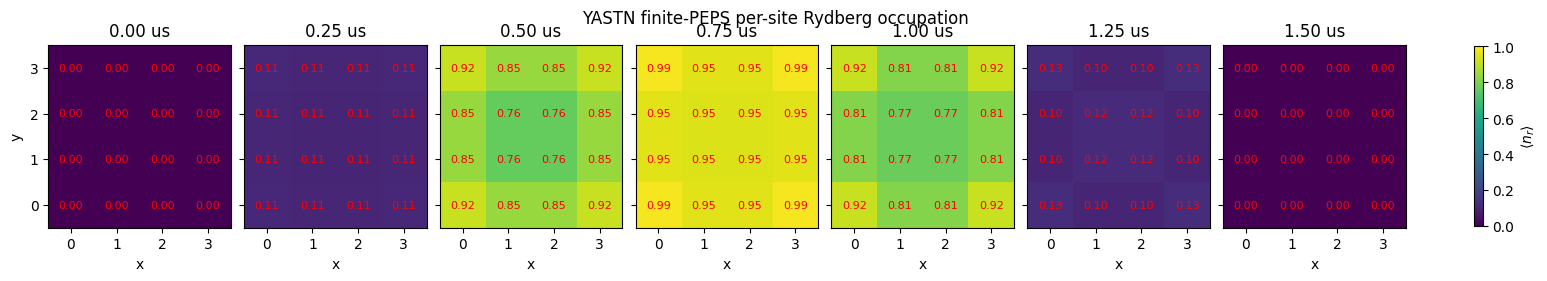

In [6]:
# 6b. 每个时刻的 4x4 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
if peps_n_i is None:
    print("peps has no successful data to plot.")
else:
    fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
    axes_h = np.atleast_1d(axes_h)

    for ax_h, t, occ in zip(axes_h, res_peps.times, peps_n_i):
        grid = occ.reshape(Lx, Ly)
        im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax_h.set_title(f"{t * 1e6:.2f} us")
        ax_h.set_xticks(range(Lx))
        ax_h.set_yticks(range(Ly))
        ax_h.set_xlabel("x")
        if ax_h is axes_h[0]:
            ax_h.set_ylabel("y")
        else:
            ax_h.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                val = grid[ix, iy]
                txt_color = "red"
                ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

    fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
    fig_h.suptitle("YASTN finite-PEPS per-site Rydberg occupation", y=1.05)
    plt.show()

In [ ]:
# 6c. 独立 10×10 finite-PEPS（YASTN backend，NTU 演化 + BP 测量）
# chi_max=8：10×10 每条 bond 饱和到 D=chi_max，NTU 每步成本随 D 陡增。
#   chi=10 → ~8 min/step（~20 h）；chi=8 → ~4.7 h（headless 实测），精度仍 << 占据数量级。
# 完整 headless 运行见 scripts/run_peps_10x10.py；下面优先加载已保存结果，无则现算。
import os

_npz_candidates = [
    "peps_10x10_results.npz",
    "../peps_10x10_results.npz",
    "scripts/peps_10x10_results.npz",
    os.path.expanduser("~/Ryd-gate-modeling/scripts/peps_10x10_results.npz"),
]
_npz = next((p for p in _npz_candidates if os.path.exists(p)), None)

if _npz is not None:
    _d = np.load(_npz)
    Lx_10, Ly_10 = int(_d["Lx"]), int(_d["Ly"])
    peps_10_times = np.asarray(_d["times"])
    peps_10_n_mean = np.asarray(_d["n_mean"])
    peps_10_n_i = np.asarray(_d["n_i"])
    peps_10_elapsed = float(_d["elapsed"])
    print(f"Loaded saved 10×10 results: {_npz}")
    print(f"  chi_max={int(_d['chi_max'])}, elapsed={peps_10_elapsed / 3600:.2f} h, "
          f"max_trunc_err={float(_d['max_truncation_error']):.2e}")
else:
    Lx_10, Ly_10 = 10, 10
    geom_10 = Register.rectangle(Lx_10, Ly_10, spacing_um=a_um)
    protocol_10 = rg.SweepProtocol(
        t_gate=t_sweep, omega_half_fn=omega_half_t, delta_fn=delta_t, n_steps=120,
    )
    system_10 = rg.RydbergSystem.from_lattice(
        geom_10, "1r",
        interaction=InteractionSpec(C6=C6_70s, mode="nn"),
        protocol=protocol_10,
    )
    _t0_10 = time.perf_counter()
    res_peps_10 = rg.simulate(
        system_10, [], "all_ground",
        backend="peps", t_eval=t_eval, observables=["n_mean", "n_i"],
        backend_options={
            "chi_max": 8,            # chi=10 在 10×10 约 20 h；chi=8 约 4.7 h
            "dt": dt_tn,
            "svd_min": 1e-8,
            "measurement_environment": "bp",
            "update_environment": "ntu",
            "max_iter": 10,
            "tol_iter": 1e-7,
            "use_cuda": True,
            "yastn_backend": "torch",
            "device": "cuda",
        },
    )
    peps_10_elapsed = time.perf_counter() - _t0_10
    peps_10_times = np.asarray(res_peps_10.times)
    peps_10_n_mean = np.asarray(res_peps_10.metadata["obs"]["n_mean"])
    peps_10_n_i = np.asarray(res_peps_10.metadata["obs"]["n_i"])

print(f"10×10 PEPS elapsed: {peps_10_elapsed:.3f} s")
print("time(us)  PEPS <n_r>")
for t, val in zip(peps_10_times * 1e6, peps_10_n_mean):
    print(f"{t:7.3f}   {val:10.4f}")

# 6c-plot. 10×10 逐格点 occupation（chi=8）
fig_h10, axes_h10 = plt.subplots(
    1, len(peps_10_times), figsize=(2.2 * len(peps_10_times), 4.5), constrained_layout=True,
)
axes_h10 = np.atleast_1d(axes_h10)

for ax_h, t, occ in zip(axes_h10, peps_10_times, peps_10_n_i):
    grid = occ.reshape(Lx_10, Ly_10)
    im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
    ax_h.set_title(f"{t * 1e6:.2f} us")
    ax_h.set_xticks(range(0, Lx_10, 2))
    ax_h.set_yticks(range(0, Ly_10, 2))

fig_h10.colorbar(im, ax=axes_h10, shrink=0.82, label=r"$\langle n_r \rangle$")
fig_h10.suptitle("10×10 finite-PEPS per-site Rydberg occupation (chi=8)", y=1.02)
plt.show()


Parts 2: Esitimation of accumulated phase
